In [1]:
# 计算多次采样的平均值
import numpy as np

def random_sampling_average():
    N = 5
    xs: list = []
    for n in range(N):
        # numpy的random.rand()函数生成[0.0, 1.0)范围内的随机浮点数，如果需要生成其他范围的随机数，可以进行相应的变换
        r = np.random.rand()
        xs.append(r)
    avg = np.average(xs)
    return avg

a = random_sampling_average()
print(a)

0.6529626103606728


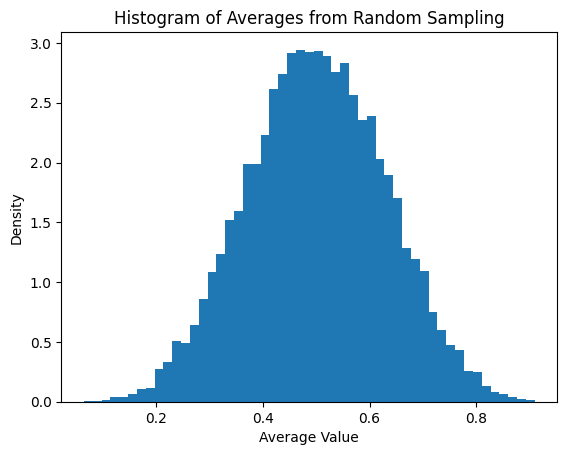

Mean of list:0.5008937306952158, and 方差: 0.016754469682464135


In [2]:
# 多次执行上面的函数，观察中心极限定理
M = 10000
averages: list = []
for m in range(M):
    avg = random_sampling_average()
    averages.append(avg)
import matplotlib.pyplot as plt
plt.hist(averages, bins='auto', density=True)
plt.title("Histogram of Averages from Random Sampling")
plt.xlabel("Average Value")
plt.ylabel("Density")
plt.show()

mu = np.average(averages)
sigma = np.std(averages)
print(f"Mean of list:{mu}, and 方差: {sigma*sigma}")


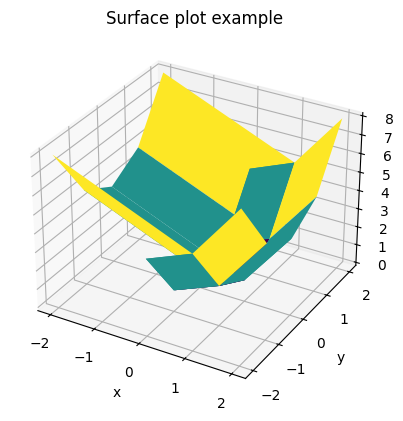

In [3]:
import numpy as np
import matplotlib.pyplot as plt
X = np.array([
    [-2, 1, 0, 1, 2],
    [-2, 1, 0, 1, 2],
    [-2, 1, 0, 1, 2],
    [-2, 1, 0, 1, 2],
    [-2, 1, 0, 1, 2],
])
Y = np.array([
    [-2, -2, -2, -2, -2],
    [-1, -1, -1, -1, -1],
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1],
    [2, 2, 2, 2, 2],
])
Z = X**2 + Y**2
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_title('Surface plot example')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

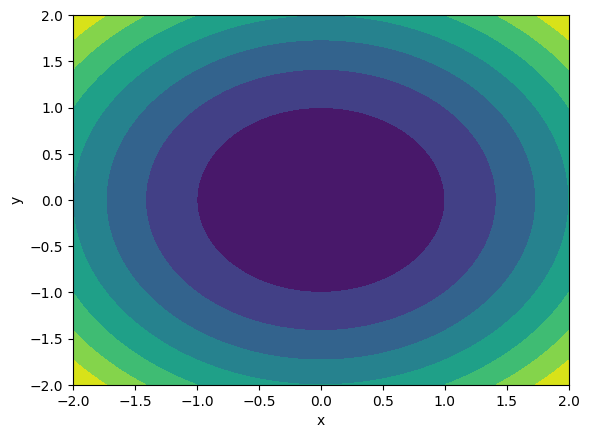

In [4]:
x: np.ndarray = np.linspace(-2, 2, 100)
y: np.ndarray = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2
ax = plt.axes()
ax.contourf(X, Y, Z, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

下面的代码是deepseek给出的关于二维正态分布的图像绘制，包括3D曲面图、等高线图、热力图，对于3D曲面图，X和Y轴形成的面，由两个面之间的体积来计算概率，可以类比到一维的标准正态分布

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20804\2454434125.py:48: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20804\2454434125.py:48: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20804\2454434125.py:48: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20804\2454434125.py:48: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20804\2454434125.py:48: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_208

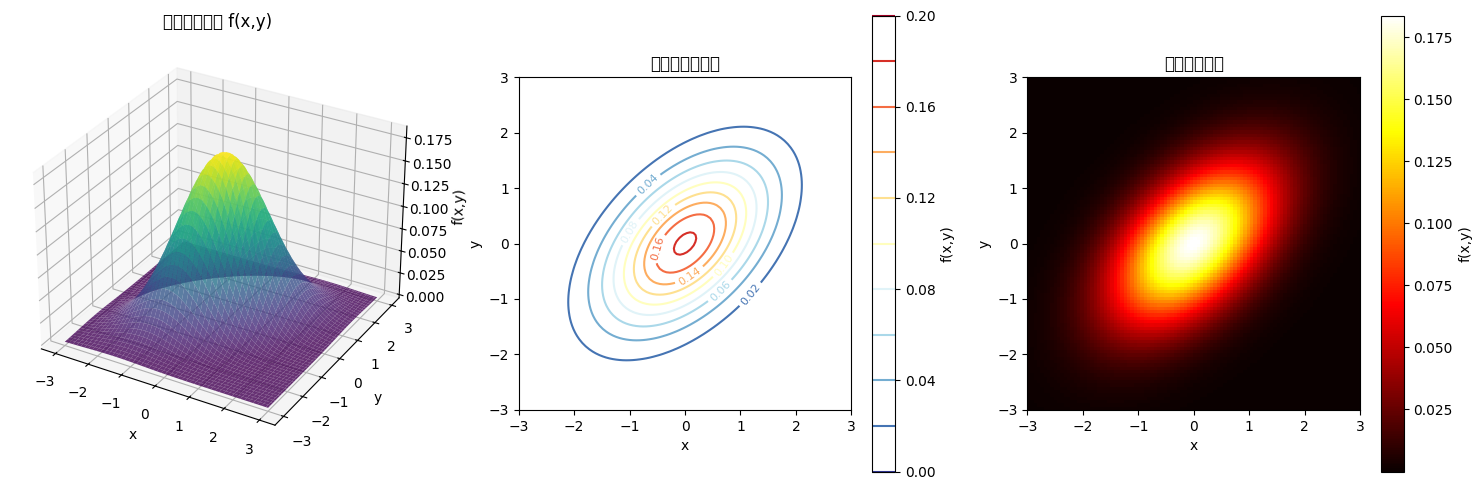

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 创建二维正态分布
mu = [0, 0]  # 均值
cov = [[1, 0.5], [0.5, 1]]  # 协方差矩阵

# 创建网格
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# 计算概率密度
rv = multivariate_normal(mu, cov)
Z = rv.pdf(pos)  # f(x,y)的值

# 可视化
fig = plt.figure(figsize=(15, 5))

# 1. 3D曲面图
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_title('概率密度曲面 f(x,y)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')

# 2. 等高线图
ax2 = fig.add_subplot(132)
contour = ax2.contour(X, Y, Z, levels=10, cmap='RdYlBu_r')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_title('概率密度等高线')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal')
plt.colorbar(contour, ax=ax2, label='f(x,y)')

# 3. 热力图
ax3 = fig.add_subplot(133)
im = ax3.imshow(Z, extent=[-3, 3, -3, 3], origin='lower', cmap='hot')
ax3.set_title('概率密度热图')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
plt.colorbar(im, ax=ax3, label='f(x,y)')

plt.tight_layout()
plt.show()

In [6]:
import torch

def func1(x):
    return x**2

x = torch.tensor(1.0, requires_grad=True)
y = func1(x)
y.backward()
print(x.grad)  # 输出 dy/dx 在 x=1 处的值，应为 2.0

tensor(2.)


下面我们使用梯度法来求解rosenbrock函数的最小值

In [7]:
import torch

def rosenbrock(x0, x1):
    return (x0 - 1)**2 + 100 * (x1 - x0**2)**2

# 定义起始点
x0 = torch.tensor(0.0, requires_grad=True)
x1 = torch.tensor(2.0, requires_grad=True)
y = rosenbrock(x0, x1)
y.backward()
print(f"起始点的梯度：x0.grad={x0.grad}, x1.grad={x1.grad}")

起始点的梯度：x0.grad=-2.0, x1.grad=400.0


使用最简单的二次函数，来测试一下梯度下降的原理

In [ ]:
import torch

x = torch.tensor(1.0, requires_grad=True)

learning_rate = 0.1

for i in range(150):
    y = x**2
    y.backward()
    print(f"x的梯度：{x.grad.item():.4f}")
    # with torch.no_grad():
    #     x -= learning_rate * x.grad
    
    # 如果对x使用了 detach(), 则不需要进行 zero_()，因为 detach() 会切断梯度计算图
    x_1 = x.detach() - learning_rate * x.grad
    x = x_1.requires_grad_(True)
    print(f"更新后的x值：{x}")
    # x.grad.zero_()

x的梯度：2.0000
更新后的x值：0.800000011920929
x的梯度：1.6000
更新后的x值：0.6399999856948853
x的梯度：1.2800
更新后的x值：0.5119999647140503
x的梯度：1.0240
更新后的x值：0.4095999598503113
x的梯度：0.8192
更新后的x值：0.32767996191978455
x的梯度：0.6554
更新后的x值：0.26214396953582764
x的梯度：0.5243
更新后的x值：0.20971517264842987
x的梯度：0.4194
更新后的x值：0.16777214407920837
x的梯度：0.3355
更新后的x值：0.13421770930290222
x的梯度：0.2684
更新后的x值：0.1073741689324379
x的梯度：0.2147
更新后的x值：0.08589933812618256
x的梯度：0.1718
更新后的x值：0.06871946901082993
x的梯度：0.1374
更新后的x值：0.05497557669878006
x的梯度：0.1100
更新后的x值：0.04398046061396599
x的梯度：0.0880
更新后的x值：0.03518436849117279
x的梯度：0.0704
更新后的x值：0.028147494420409203
x的梯度：0.0563
更新后的x值：0.022517995908856392
x的梯度：0.0450
更新后的x值：0.018014397472143173
x的梯度：0.0360
更新后的x值：0.014411518350243568
x的梯度：0.0288
更新后的x值：0.011529214680194855
x的梯度：0.0231
更新后的x值：0.009223371744155884
x的梯度：0.0184
更新后的x值：0.007378697395324707
x的梯度：0.0148
更新后的x值：0.0059029581025242805
x的梯度：0.0118
更新后的x值：0.004722366575151682
x的梯度：0.0094
更新后的x值：0.0037778932601213455
x的梯度：0.0076
更新后的x值：

除了普通的一元二次函数之外，下面测试一下二元二次函数的梯度下降
α

In [ ]:
import torch

def rosenbrock(x0, x1):
    return (x0 - 1)**2 + 100 * (x1 - x0**2)**2

# 定义起始点
x0 = torch.tensor(0.0, requires_grad=True)
x1 = torch.tensor(2.0, requires_grad=True)
learning_rate = 0.001
for i in range(20000):
    y = rosenbrock(x0, x1)
    y.backward()
    print(f"梯度：x0.grad={x0.grad.item():.4f}, x1.grad={x1.grad.item():.4f}")
    x0_1 = x0.detach() - learning_rate * x0.grad
    x1_1 = x1.detach() - learning_rate * x1.grad
    x0 = x0_1.requires_grad_(True)
    x1 = x1_1.requires_grad_(True)
    print(f"更新后的值：x0={x0.item():.4f}, x1={x1.item():.4f}")

使用pytorch中自带的计算梯度的函数，来实现求解二元一次方程的最小值

In [19]:
import torch

x = torch.tensor(1.0, requires_grad=True)

learning_rate = 0.1

y = x**2

y.backward()
print(f"x的梯度：{x.grad.item():.4f}")

x的梯度：2.0000
